# Notebook 3 - Inverse dynamica met zwaartekracht en wrijving

Deze notebook breidt de dynamica van het stangenmechanisme uit met de belastingen die in Notebook 2 bewust nog buiten beschouwing bleven. Notebook 1 levert de kinematica van de positiegestuurde schuiver, Notebook 2 levert de inertiele inverse dynamica en de massa-/inertieparameters. Hier worden daar zwaartekracht, schuiverwrijving, scharnierwrijving en statische houdkracht aan toegevoegd.

Workflow:

1. Run `Notebook 1 - Examen.ipynb` om `notebook1_kinematica_results.npz` te vernieuwen.
2. Run `Notebook 2.ipynb` om de inertiele dynamica en massa-instellingen te vernieuwen.
3. Run deze notebook om zwaartekracht, wrijving, houdkracht en actuatorbelasting met externe lasten te berekenen.

## Setup en data

De notebook leest dezelfde kinematische grootheden als Notebook 2. Daarnaast wordt `notebook2_dynamica_results.npz` geladen, zodat massa's, inerties en puntmassa K consistent blijven met de vorige notebooks.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

kinematics_path = Path("notebook1_kinematica_results.npz")
dynamics_path = Path("notebook2_dynamica_results.npz")
if not kinematics_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 1 - Examen.ipynb' zodat notebook1_kinematica_results.npz bestaat.")
if not dynamics_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 2.ipynb' zodat notebook2_dynamica_results.npz bestaat.")

kin_required = [
    "t", "Ts", "s", "ds", "dds",
    "theta3", "theta4", "theta5", "theta6", "theta7", "theta8",
    "dtheta3", "dtheta4", "dtheta5", "dtheta6", "dtheta7", "dtheta8",
    "ddtheta3", "ddtheta4", "ddtheta5", "ddtheta6", "ddtheta7", "ddtheta8",
    "Kx", "Ky", "Kdot_x", "Kdot_y", "Kdot_norm", "Kddot_x", "Kddot_y", "Kddot_norm",
    "cond", "residual_pos",
    "L1", "r3a", "r3b", "r4a", "r4b", "r5a", "r5b", "r6", "r7a", "r7b", "r8a", "r8b",
]
dyn_required = [
    "F_drive_s", "R_Ax", "C_x", "C_y", "M_A", "w_all", "unknown_labels",
    "masses", "inertias", "payload_mass_K", "line_mass_density", "slider_mass", "total_model_mass",
]
kin = np.load(kinematics_path)
dyn = np.load(dynamics_path, allow_pickle=True)
missing_kin = [key for key in kin_required if key not in kin.files]
missing_dyn = [key for key in dyn_required if key not in dyn.files]
if missing_kin:
    raise KeyError(f"Ontbrekende keys in {kinematics_path}: {missing_kin}")
if missing_dyn:
    raise KeyError(f"Ontbrekende keys in {dynamics_path}: {missing_dyn}")

t = kin["t"]; Ts = float(kin["Ts"]); s = kin["s"]; ds = kin["ds"]; dds = kin["dds"]
n_steps = len(t); T_cycle = float(t[-1] - t[0])
theta3 = kin["theta3"]; theta4 = kin["theta4"]; theta5 = kin["theta5"]
theta6 = kin["theta6"]; theta7 = kin["theta7"]; theta8 = kin["theta8"]
dtheta3 = kin["dtheta3"]; dtheta4 = kin["dtheta4"]; dtheta5 = kin["dtheta5"]
dtheta6 = kin["dtheta6"]; dtheta7 = kin["dtheta7"]; dtheta8 = kin["dtheta8"]
ddtheta3 = kin["ddtheta3"]; ddtheta4 = kin["ddtheta4"]; ddtheta5 = kin["ddtheta5"]
ddtheta6 = kin["ddtheta6"]; ddtheta7 = kin["ddtheta7"]; ddtheta8 = kin["ddtheta8"]
Kx = kin["Kx"]; Ky = kin["Ky"]; Kdot_x = kin["Kdot_x"]; Kdot_y = kin["Kdot_y"]
Kdot_norm = kin["Kdot_norm"]; Kddot_x = kin["Kddot_x"]; Kddot_y = kin["Kddot_y"]; Kddot_norm = kin["Kddot_norm"]
cond = kin["cond"]; residual_pos = kin["residual_pos"]
L1 = float(kin["L1"]); r3a = float(kin["r3a"]); r3b = float(kin["r3b"])
r4a = float(kin["r4a"]); r4b = float(kin["r4b"]); r5a = float(kin["r5a"]); r5b = float(kin["r5b"])
r6 = float(kin["r6"]); r7a = float(kin["r7a"]); r7b = float(kin["r7b"]); r8a = float(kin["r8a"]); r8b = float(kin["r8b"])
L2 = 0.0; L3 = r3a + r3b; L4 = r4a + r4b; L5 = r5a + r5b; L6 = r6; L7 = r7a + r7b; L8 = r8a + r8b

unknown_labels = [str(x) for x in dyn["unknown_labels"]]
unknown_index = {name: i for i, name in enumerate(unknown_labels)}
n_unknowns = len(unknown_labels)
w_inertia_notebook2 = dyn["w_all"]
F_drive_s_inertia = dyn["F_drive_s"]
R_Ax_inertia = dyn["R_Ax"]
C_x_inertia = dyn["C_x"]; C_y_inertia = dyn["C_y"]; M_A_inertia = dyn["M_A"]
mass_array = dyn["masses"].astype(float); inertia_array = dyn["inertias"].astype(float)
masses = {link_id: mass_array[link_id - 2] for link_id in range(2, 9)}
inertias = {link_id: inertia_array[link_id - 2] for link_id in range(2, 9)}
payload_mass_K = float(dyn["payload_mass_K"])
line_mass_density = float(dyn["line_mass_density"])
slider_mass = float(dyn["slider_mass"])
total_model_mass = float(dyn["total_model_mass"])

expected_labels = [
    "R_Ax", "F_act_y", "M_A", "C_x", "C_y", "B_x", "B_y", "D_x", "D_y", "E_x", "E_y",
    "F_x", "F_y", "G_x", "G_y", "H_x", "H_y", "I_x", "I_y", "J_x", "J_y",
]
if unknown_labels != expected_labels:
    raise ValueError("De onbekenden uit Notebook 2 hebben niet de verwachte volgorde.")

print("Data ingeladen:")
print(kinematics_path.resolve())
print(dynamics_path.resolve())
print(f"Aantal tijdstappen: {n_steps}")
print(f"Totale simulatieduur: {T_cycle:.3f} s")
print(f"Totale bewegende modelmassa incl. K: {total_model_mass:.3f} kg")
print(f"Puntmassa K: {payload_mass_K:.3f} kg")
print(f"max sluitingsfout Notebook 1: {np.max(residual_pos):.3e}")

Data ingeladen:
C:\Users\alecv\Git\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook1_kinematica_results.npz
C:\Users\alecv\Git\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook2_dynamica_results.npz
Aantal tijdstappen: 682
Totale simulatieduur: 34.050 s
Totale bewegende modelmassa incl. K: 7.500 kg
Puntmassa K: 3.000 kg
max sluitingsfout Notebook 1: 5.779e-13


## Parameters

Positieve `s` wijst naar beneden; openen betekent meestal `ds < 0`. Zwaartekracht werkt in negatieve globale `y`-richting. De wrijving wordt bewust instelbaar gehouden, omdat ze in een echte paraplu sterk afhangt van de gekozen geleiding, lagerbusjes, smering en montagekwaliteit.

De standaardinstelling gebruikt vooral Coulombwrijving, zoals in de lesvoorbeelden. De viskeuze term staat standaard op nul: die is alleen nuttig als men later een empirische demping of actuator-/geleidingsdemping wil toevoegen. De scharnierwrijving blijft een eenvoudige bus-/pinbenadering; ze is fysisch verdedigbaar, maar minder rechtstreeks uit de lessen af te lezen dan de Coulombwrijving `mu*N`.

In [2]:
with_gravity = True
g = 9.81
g_vec = np.array([0.0, -g])

# Schuivergeleiding. Voor een grote paraplu is een lage-wrijving geleiding of rollende collar realistischer
# dan droge metaal-op-metaal schuifwrijving. Verhoog mu_slider als je een slechtere glijgeleiding wil testen.
mu_slider = 0.05
mu_slider_static = 0.08
c_slider = 0.0
v_eps = 1e-3

# Scharnier-/buswrijving. Dit is een eenvoudige Coulomb-benadering met pinradius.
include_pin_friction = True
mu_pin = 0.05
pin_radius = 0.006
omega_eps = 1e-3
friction_iterations = 3
friction_tol = 1e-8

actuator_efficiency = 0.80
actuator_safety_factor = 1.50
screw_lead = 0.005

print("Belastingsparameters:")
print(f"g = {g:.2f} m/s^2")
print(f"mu_slider = {mu_slider:.3f}, mu_slider_static = {mu_slider_static:.3f}, c_slider = {c_slider:.2f} N s/m")
print(f"mu_pin = {mu_pin:.3f}, pin_radius = {pin_radius*1000:.1f} mm, scharnierwrijving actief = {include_pin_friction}")
print(f"screw_lead = {screw_lead:.4f} m/omw, actuator_efficiency = {actuator_efficiency:.2f}")

Belastingsparameters:
g = 9.81 m/s^2
mu_slider = 0.050, mu_slider_static = 0.080, c_slider = 0.00 N s/m
mu_pin = 0.050, pin_radius = 6.0 mm, scharnierwrijving actief = True
screw_lead = 0.0050 m/omw, actuator_efficiency = 0.80


## Rigid-body kinematica

De punten en zwaartepunten worden op dezelfde manier gereconstrueerd als in Notebook 2. Punt K blijft een aparte puntmassa die aan link 8 gekoppeld is.

In [3]:
def perp(v):
    v = np.asarray(v)
    return np.column_stack((-v[:, 1], v[:, 0])) if v.ndim == 2 else np.array([-v[1], v[0]])

def rigid_point(ref_pos, ref_vel, ref_acc, theta, omega, alpha_val, local_vector):
    local_vector = np.asarray(local_vector, dtype=float)
    r_global = np.column_stack((
        local_vector[0] * np.cos(theta) - local_vector[1] * np.sin(theta),
        local_vector[0] * np.sin(theta) + local_vector[1] * np.cos(theta),
    ))
    pos = ref_pos + r_global
    vel = ref_vel + omega[:, None] * perp(r_global)
    acc = ref_acc + alpha_val[:, None] * perp(r_global) - (omega[:, None] ** 2) * r_global
    return pos, vel, acc

zero = np.zeros(n_steps); zeros2 = np.zeros((n_steps, 2))
C_pos = zeros2.copy(); C_vel = zeros2.copy(); C_acc = zeros2.copy()
B_pos = np.column_stack((zero, -s)); B_vel = np.column_stack((zero, -ds)); B_acc = np.column_stack((zero, -dds))

D_pos, D_vel, D_acc = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a, 0.0])
E3_pos, _, _ = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a + r3b, 0.0])
E4_pos, _, _ = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a, 0.0])
E_pos = 0.5 * (E3_pos + E4_pos)
H_pos, H_vel, H_acc = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a + r4b, 0.0])
F_pos, F_vel, F_acc = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a, 0.0])
G5_pos, _, _ = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a + r5b, 0.0])
G7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [-r7a, 0.0])
G_pos = 0.5 * (G5_pos + G7_pos)
I_pos, I_vel, I_acc = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [r6, 0.0])
J7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [r7b, 0.0])
J8_pos, _, _ = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a, 0.0])
J_pos = 0.5 * (J7_pos + J8_pos)
K_pos, K_vel, K_acc = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a + r8b, 0.0])

cg_pos, cg_vel, cg_acc, alpha = {}, {}, {}, {}
cg_pos[2] = B_pos.copy(); cg_vel[2] = B_vel.copy(); cg_acc[2] = B_acc.copy(); alpha[2] = zero.copy()
cg_pos[3], cg_vel[3], cg_acc[3] = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [L3 / 2, 0.0]); alpha[3] = ddtheta3
cg_pos[4], cg_vel[4], cg_acc[4] = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [L4 / 2, 0.0]); alpha[4] = ddtheta4
cg_pos[5], cg_vel[5], cg_acc[5] = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [L5 / 2, 0.0]); alpha[5] = ddtheta5
cg_pos[6], cg_vel[6], cg_acc[6] = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [L6 / 2, 0.0]); alpha[6] = ddtheta6
cg_pos[7], cg_vel[7], cg_acc[7] = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [(r7b - r7a) / 2, 0.0]); alpha[7] = ddtheta7
cg_pos[8], cg_vel[8], cg_acc[8] = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [L8 / 2, 0.0]); alpha[8] = ddtheta8

K_loaded = np.column_stack((Kx, Ky))
print("Rigid-body kinematica opgebouwd.")
print(f"max |K_reconstructie - K_Notebook1| = {np.max(np.linalg.norm(K_pos - K_loaded, axis=1)):.3e} m")
print(f"max sluitverschil E/G/J = {np.max(np.linalg.norm(E3_pos - E4_pos, axis=1)):.3e} / {np.max(np.linalg.norm(G5_pos - G7_pos, axis=1)):.3e} / {np.max(np.linalg.norm(J7_pos - J8_pos, axis=1)):.3e} m")

Rigid-body kinematica opgebouwd.
max |K_reconstructie - K_Notebook1| = 4.578e-16 m
max sluitverschil E/G/J = 5.779e-13 / 5.782e-13 / 5.778e-13 m


## Inverse dynamica met bekende krachten

De onbekenden blijven dezelfde als in Notebook 2. Bekende externe krachten, zoals zwaartekracht en wrijving, worden expliciet naar de rechterkant gebracht. De puntmassa in K wordt als extra belasting op link 8 behandeld met `m_K(a_K - g_vec)`.

In [4]:
def moment_2d(r, F):
    return r[0] * F[1] - r[1] * F[0]

def link_acc(link_id, k, static=False):
    return np.zeros(2) if static else cg_acc[link_id][k]

def link_alpha(link_id, k, static=False):
    return 0.0 if static else alpha[link_id][k]

def point_acc_K(k, static=False):
    return np.zeros(2) if static else K_acc[k]

def add_link_equations(A, b, row, m, J, a_cg, alpha_cg, cg, forces, known_forces=None, known_moments=None, point_loads=None, unknown_moments=None):
    known_forces = known_forces or []
    known_moments = known_moments or []
    point_loads = point_loads or []
    unknown_moments = unknown_moments or []
    row_fx, row_fy, row_m = row, row + 1, row + 2
    for fx_name, fy_name, sign, point in forces:
        r = point - cg
        if fx_name is not None:
            j = unknown_index[fx_name]
            A[row_fx, j] += sign
            A[row_m, j] += -sign * r[1]
        if fy_name is not None:
            j = unknown_index[fy_name]
            A[row_fy, j] += sign
            A[row_m, j] += sign * r[0]

    F_rhs = m * a_cg
    M_rhs = J * alpha_cg
    for moment_name, sign in unknown_moments:
        A[row_m, unknown_index[moment_name]] += sign

    for F_known, point in known_forces:
        r = point - cg
        F_rhs = F_rhs - F_known
        M_rhs = M_rhs - moment_2d(r, F_known)
    for M_known in known_moments:
        M_rhs = M_rhs - M_known
    for F_eff, point in point_loads:
        r = point - cg
        F_rhs = F_rhs + F_eff
        M_rhs = M_rhs + moment_2d(r, F_eff)

    b[row_fx] = F_rhs[0]
    b[row_fy] = F_rhs[1]
    b[row_m] = M_rhs
    return row + 3

def gravity_force(link_id):
    return masses[link_id] * g_vec

def build_inverse_dynamics_system(k, include_gravity=True, slider_friction_s=0.0, pin_moments_by_link=None, static=False):
    pin_moments_by_link = pin_moments_by_link or {}
    A = np.zeros((n_unknowns, n_unknowns)); b = np.zeros(n_unknowns); row = 0

    def known_forces_for(link_id):
        known = []
        if include_gravity:
            known.append((gravity_force(link_id), cg_pos[link_id][k]))
        if link_id == 2 and slider_friction_s != 0.0:
            known.append((np.array([0.0, -slider_friction_s]), B_pos[k]))
        return known

    def known_moments_for(link_id):
        M = pin_moments_by_link.get(link_id, 0.0)
        return [M] if M != 0.0 else []

    row = add_link_equations(A, b, row, masses[2], inertias[2], link_acc(2, k, static), link_alpha(2, k, static), cg_pos[2][k],
                             [("R_Ax", None, 1.0, B_pos[k]), (None, "F_act_y", 1.0, B_pos[k]), ("B_x", "B_y", 1.0, B_pos[k])],
                             known_forces=known_forces_for(2), known_moments=known_moments_for(2),
                             unknown_moments=[("M_A", 1.0)])
    row = add_link_equations(A, b, row, masses[3], inertias[3], link_acc(3, k, static), link_alpha(3, k, static), cg_pos[3][k],
                             [("B_x", "B_y", -1.0, B_pos[k]), ("D_x", "D_y", 1.0, D_pos[k]), ("E_x", "E_y", 1.0, E_pos[k])],
                             known_forces=known_forces_for(3), known_moments=known_moments_for(3))
    row = add_link_equations(A, b, row, masses[4], inertias[4], link_acc(4, k, static), link_alpha(4, k, static), cg_pos[4][k],
                             [("C_x", "C_y", 1.0, C_pos[k]), ("E_x", "E_y", -1.0, E_pos[k]), ("H_x", "H_y", 1.0, H_pos[k])],
                             known_forces=known_forces_for(4), known_moments=known_moments_for(4))
    row = add_link_equations(A, b, row, masses[5], inertias[5], link_acc(5, k, static), link_alpha(5, k, static), cg_pos[5][k],
                             [("D_x", "D_y", -1.0, D_pos[k]), ("F_x", "F_y", 1.0, F_pos[k]), ("G_x", "G_y", 1.0, G_pos[k])],
                             known_forces=known_forces_for(5), known_moments=known_moments_for(5))
    row = add_link_equations(A, b, row, masses[6], inertias[6], link_acc(6, k, static), link_alpha(6, k, static), cg_pos[6][k],
                             [("F_x", "F_y", -1.0, F_pos[k]), ("I_x", "I_y", 1.0, I_pos[k])],
                             known_forces=known_forces_for(6), known_moments=known_moments_for(6))
    row = add_link_equations(A, b, row, masses[7], inertias[7], link_acc(7, k, static), link_alpha(7, k, static), cg_pos[7][k],
                             [("G_x", "G_y", -1.0, G_pos[k]), ("H_x", "H_y", -1.0, H_pos[k]), ("J_x", "J_y", 1.0, J_pos[k])],
                             known_forces=known_forces_for(7), known_moments=known_moments_for(7))
    K_eff = payload_mass_K * (point_acc_K(k, static) - (g_vec if include_gravity else np.zeros(2)))
    row = add_link_equations(A, b, row, masses[8], inertias[8], link_acc(8, k, static), link_alpha(8, k, static), cg_pos[8][k],
                             [("I_x", "I_y", -1.0, I_pos[k]), ("J_x", "J_y", -1.0, J_pos[k])],
                             known_forces=known_forces_for(8), known_moments=known_moments_for(8),
                             point_loads=[(K_eff, K_pos[k])])
    if row != n_unknowns:
        raise RuntimeError(f"Verkeerd aantal vergelijkingen: {row} i.p.v. {n_unknowns}")
    return A, b

## Wrijvingsmodel

De schuiverwrijving werkt tegen de schuiverbeweging. De scharnierwrijving werkt tegen de relatieve hoeksnelheid tussen de twee verbonden links. Voor elk scharnier worden gelijke en tegengestelde momenten toegevoegd aan de twee verbonden lichamen.

Dit is een uitbreiding van de lesaanpak: de lessen gebruiken Coulombwrijving van de vorm `mu*N`; hier wordt hetzelfde principe toegepast op de schuivergeleiding en op de pennen. De actuator-efficiëntie wordt niet als extra mechanische kracht in het mechanisme gezet, maar pas achteraf gebruikt bij het motorvermogen.

In [5]:
omega_link = {0: zero, 2: zero, 3: dtheta3, 4: dtheta4, 5: dtheta5, 6: dtheta6, 7: dtheta7, 8: dtheta8}
pin_joint_defs = [
    ("B", 3, 2, "B_x", "B_y"),
    ("C", 4, 0, "C_x", "C_y"),
    ("D", 5, 3, "D_x", "D_y"),
    ("E", 3, 4, "E_x", "E_y"),
    ("F", 6, 5, "F_x", "F_y"),
    ("G", 5, 7, "G_x", "G_y"),
    ("H", 4, 7, "H_x", "H_y"),
    ("I", 8, 6, "I_x", "I_y"),
    ("J", 7, 8, "J_x", "J_y"),
]
pin_joint_names = [item[0] for item in pin_joint_defs]

def reaction_norm_from_solution(w, fx_name, fy_name):
    return float(np.hypot(w[unknown_index[fx_name]], w[unknown_index[fy_name]]))

def compute_slider_friction_s(k, w_guess):
    N_slider = abs(float(w_guess[unknown_index["R_Ax"]]))
    F_coulomb = -mu_slider * N_slider * np.tanh(ds[k] / v_eps)
    F_viscous = -c_slider * ds[k]
    return F_coulomb + F_viscous, N_slider

def compute_pin_friction(k, w_guess):
    moments_by_link = {link_id: 0.0 for link_id in range(2, 9)}
    joint_moments = np.zeros(len(pin_joint_defs))
    joint_normal = np.zeros(len(pin_joint_defs))
    joint_power_loss = np.zeros(len(pin_joint_defs))
    if not include_pin_friction:
        return moments_by_link, joint_moments, joint_normal, joint_power_loss
    for j, (name, link_a, link_b, fx_name, fy_name) in enumerate(pin_joint_defs):
        N_joint = reaction_norm_from_solution(w_guess, fx_name, fy_name)
        omega_rel = omega_link[link_a][k] - omega_link[link_b][k]
        M_base = mu_pin * pin_radius * N_joint * np.tanh(omega_rel / omega_eps)
        M_on_a = -M_base
        M_on_b = M_base
        if link_a in moments_by_link:
            moments_by_link[link_a] += M_on_a
        if link_b in moments_by_link:
            moments_by_link[link_b] += M_on_b
        joint_moments[j] = M_on_a
        joint_normal[j] = N_joint
        joint_power_loss[j] = max(0.0, -(M_on_a * omega_link[link_a][k] + M_on_b * omega_link[link_b][k]))
    return moments_by_link, joint_moments, joint_normal, joint_power_loss

def solve_case(include_gravity=True, include_friction=False, static=False):
    w_case = np.zeros((n_steps, n_unknowns))
    residual = np.zeros(n_steps); cond_dyn = np.zeros(n_steps)
    F_slider_friction_s = np.zeros(n_steps); N_slider = np.zeros(n_steps)
    joint_friction_moments = np.zeros((n_steps, len(pin_joint_defs)))
    joint_normal_forces = np.zeros((n_steps, len(pin_joint_defs)))
    joint_power_loss = np.zeros((n_steps, len(pin_joint_defs)))
    friction_iteration_delta = np.zeros(n_steps)

    for k in range(n_steps):
        A0, b0 = build_inverse_dynamics_system(k, include_gravity=include_gravity, static=static)
        w_current = np.linalg.solve(A0, b0)
        if include_friction:
            last_delta = 0.0
            for _ in range(friction_iterations):
                F_slider, N_val = compute_slider_friction_s(k, w_current)
                M_by_link, M_joints, N_joints, P_loss = compute_pin_friction(k, w_current)
                A_k, b_k = build_inverse_dynamics_system(
                    k,
                    include_gravity=include_gravity,
                    slider_friction_s=F_slider,
                    pin_moments_by_link=M_by_link,
                    static=static,
                )
                w_next = np.linalg.solve(A_k, b_k)
                last_delta = np.linalg.norm(w_next - w_current)
                w_current = w_next
                if last_delta < friction_tol:
                    break
        else:
            F_slider = 0.0
            N_val = abs(float(w_current[unknown_index["R_Ax"]]))
            M_joints = np.zeros(len(pin_joint_defs))
            N_joints = np.array([reaction_norm_from_solution(w_current, item[3], item[4]) for item in pin_joint_defs])
            P_loss = np.zeros(len(pin_joint_defs))
            A_k, b_k = A0, b0
            last_delta = 0.0
        w_case[k] = w_current
        residual[k] = np.linalg.norm(A_k @ w_current - b_k)
        cond_dyn[k] = np.linalg.cond(A_k)
        F_slider_friction_s[k] = F_slider
        N_slider[k] = N_val
        joint_friction_moments[k] = M_joints
        joint_normal_forces[k] = N_joints
        joint_power_loss[k] = P_loss
        friction_iteration_delta[k] = last_delta
    return {
        "w": w_case,
        "residual": residual,
        "cond": cond_dyn,
        "F_slider_friction_s": F_slider_friction_s,
        "N_slider": N_slider,
        "joint_friction_moments": joint_friction_moments,
        "joint_normal_forces": joint_normal_forces,
        "joint_power_loss": joint_power_loss,
        "friction_iteration_delta": friction_iteration_delta,
    }

## Oplossingen en controles

Eerst wordt gecontroleerd dat de oplossing zonder zwaartekracht en zonder wrijving samenvalt met Notebook 2. Daarna volgen de oplossing met zwaartekracht en de totale oplossing met zwaartekracht plus wrijving.

In [6]:
case_inertia_check = solve_case(include_gravity=False, include_friction=False)
case_gravity = solve_case(include_gravity=True, include_friction=False)
case_total = solve_case(include_gravity=True, include_friction=True)

def unpack_case(case):
    return {name: case["w"][:, idx] for name, idx in unknown_index.items()}

vars_inertia_check = unpack_case(case_inertia_check)
vars_gravity = unpack_case(case_gravity)
vars_total = unpack_case(case_total)

F_drive_s_inertia_check = -vars_inertia_check["F_act_y"]
F_drive_s_gravity = -vars_gravity["F_act_y"]
F_drive_s_total = -vars_total["F_act_y"]
F_gravity_component = F_drive_s_gravity - F_drive_s_inertia
F_friction_component = F_drive_s_total - F_drive_s_gravity

# De schuiverwrijvingskracht zelf werkt op de schuiver in positieve s-richting bij openen.
# In de benodigde aandrijfkracht verschijnt ze met tegengesteld teken.
F_slider_drive_component = -case_total["F_slider_friction_s"]
F_pin_friction_component = F_friction_component - F_slider_drive_component

active_motion_mask = np.abs(ds) > 1e-6
if not np.any(active_motion_mask):
    active_motion_mask = np.ones_like(ds, dtype=bool)
s_motion = s[active_motion_mask]
sort_motion = np.argsort(s_motion)

max_diff_notebook2 = np.max(np.abs(F_drive_s_inertia_check - F_drive_s_inertia))
friction_sign_check = np.max(case_total["F_slider_friction_s"][active_motion_mask] * ds[active_motion_mask])

print("Dynamische controles:")
print(f"max |F_inertie_check - F_Notebook2| = {max_diff_notebook2:.3e} N")
print(f"max residu zwaartekracht             = {np.max(case_gravity['residual']):.3e}")
print(f"max residu totaal                    = {np.max(case_total['residual']):.3e}")
print(f"cond(A) totaal min/gem/max           = {np.min(case_total['cond']):.3e} / {np.mean(case_total['cond']):.3e} / {np.max(case_total['cond']):.3e}")
print(f"max iteratieverandering wrijving     = {np.max(case_total['friction_iteration_delta']):.3e}")
print(f"max(F_fric_slider_s * ds)            = {friction_sign_check:.3e} W-equivalent")
print()
print("Aandrijfkrachtcomponenten:")
print(f"max |F_s| inertie                    = {np.max(np.abs(F_drive_s_inertia)):.3f} N")
print(f"max |F_s| zwaartekrachtcomponent     = {np.max(np.abs(F_gravity_component)):.3f} N")
print(f"max |F_s| schuiverwrijvingcomponent  = {np.max(np.abs(F_slider_drive_component)):.3f} N")
print(f"max |F_s| scharnierwrijving/effect   = {np.max(np.abs(F_pin_friction_component)):.3f} N")
print(f"max |F_s| totaal                     = {np.max(np.abs(F_drive_s_total)):.3f} N")
print(f"RMS |F_s| totaal tijdens beweging    = {np.sqrt(np.mean(F_drive_s_total[active_motion_mask]**2)):.3f} N")

Dynamische controles:
max |F_inertie_check - F_Notebook2| = 0.000e+00 N
max residu zwaartekracht             = 1.375e-13
max residu totaal                    = 1.394e-13
cond(A) totaal min/gem/max           = 1.877e+01 / 1.117e+02 / 2.167e+02
max iteratieverandering wrijving     = 4.428e-03
max(F_fric_slider_s * ds)            = -1.436e-10 W-equivalent

Aandrijfkrachtcomponenten:
max |F_s| inertie                    = 3.173 N
max |F_s| zwaartekrachtcomponent     = 63.432 N
max |F_s| schuiverwrijvingcomponent  = 38.319 N
max |F_s| scharnierwrijving/effect   = 1.800 N
max |F_s| totaal                     = 76.062 N
RMS |F_s| totaal tijdens beweging    = 66.977 N


## Krachtdecompositie

De totale schuifkracht is:

`F_s,totaal = F_s,inertie + F_s,zwaartekracht + F_s,wrijving`.

De inertiële term komt overeen met Notebook 2. De zwaartekrachtterm is het verschil tussen de oplossing met zwaartekracht en de oplossing zonder zwaartekracht. De wrijvingsterm bestaat uit de schuiverwrijving en de equivalente invloed van scharnierwrijving. Plots tegenover `s` gebruiken alleen de effectieve beweging, zodat de hold-fases geen verticale lijnen veroorzaken.

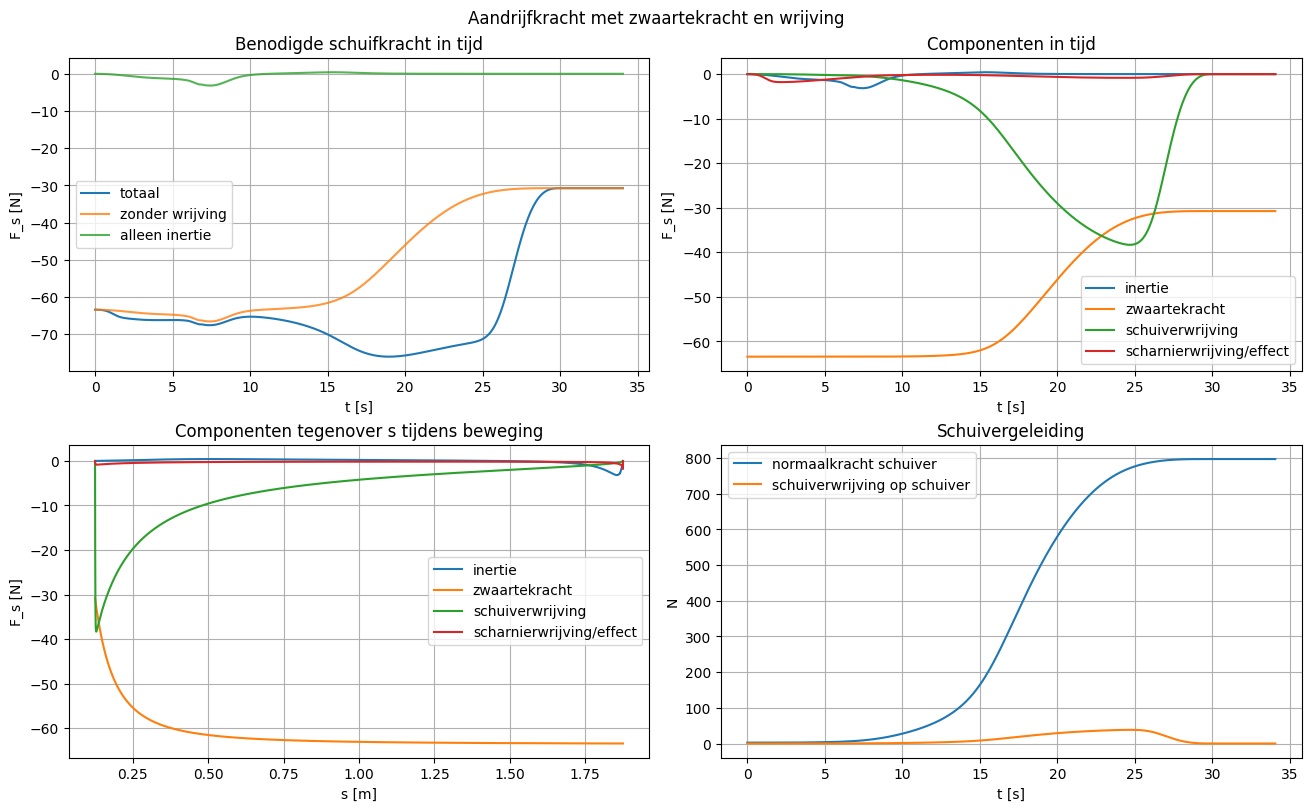

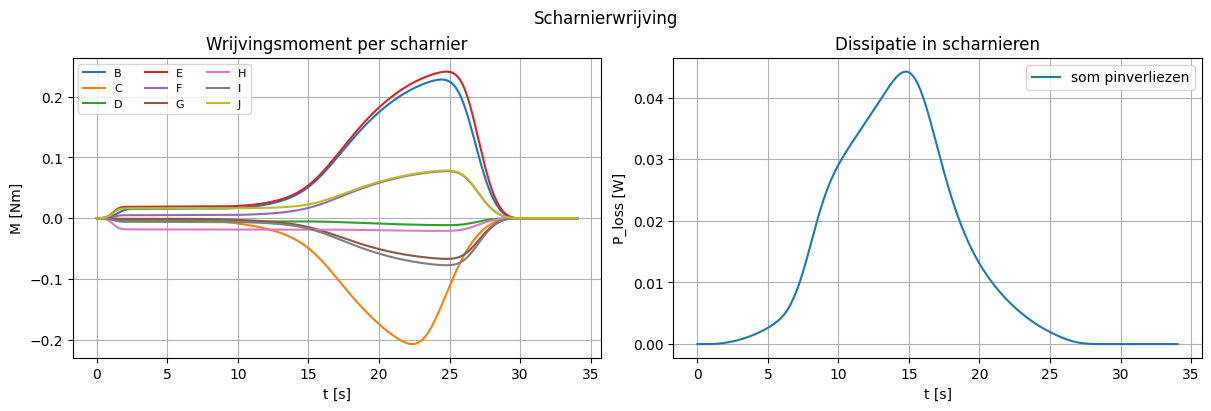

In [7]:
fig_force, ax_force = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
fig_force.suptitle("Aandrijfkracht met zwaartekracht en wrijving")

ax_force[0, 0].plot(t, F_drive_s_total, label="totaal", color="tab:blue")
ax_force[0, 0].plot(t, F_drive_s_gravity, label="zonder wrijving", color="tab:orange", alpha=0.8)
ax_force[0, 0].plot(t, F_drive_s_inertia, label="alleen inertie", color="tab:green", alpha=0.8)
ax_force[0, 0].set_title("Benodigde schuifkracht in tijd")
ax_force[0, 0].set_xlabel("t [s]"); ax_force[0, 0].set_ylabel("F_s [N]")
ax_force[0, 0].grid(True); ax_force[0, 0].legend()

ax_force[0, 1].plot(t, F_drive_s_inertia, label="inertie")
ax_force[0, 1].plot(t, F_gravity_component, label="zwaartekracht")
ax_force[0, 1].plot(t, F_slider_drive_component, label="schuiverwrijving")
ax_force[0, 1].plot(t, F_pin_friction_component, label="scharnierwrijving/effect")
ax_force[0, 1].set_title("Componenten in tijd")
ax_force[0, 1].set_xlabel("t [s]"); ax_force[0, 1].set_ylabel("F_s [N]")
ax_force[0, 1].grid(True); ax_force[0, 1].legend()

ax_force[1, 0].plot(s_motion[sort_motion], F_drive_s_inertia[active_motion_mask][sort_motion], label="inertie")
ax_force[1, 0].plot(s_motion[sort_motion], F_gravity_component[active_motion_mask][sort_motion], label="zwaartekracht")
ax_force[1, 0].plot(s_motion[sort_motion], F_slider_drive_component[active_motion_mask][sort_motion], label="schuiverwrijving")
ax_force[1, 0].plot(s_motion[sort_motion], F_pin_friction_component[active_motion_mask][sort_motion], label="scharnierwrijving/effect")
ax_force[1, 0].set_title("Componenten tegenover s tijdens beweging")
ax_force[1, 0].set_xlabel("s [m]"); ax_force[1, 0].set_ylabel("F_s [N]")
ax_force[1, 0].grid(True); ax_force[1, 0].legend()

ax_force[1, 1].plot(t, case_total["N_slider"], label="normaalkracht schuiver")
ax_force[1, 1].plot(t, -F_slider_drive_component, label="schuiverwrijving op schuiver")
ax_force[1, 1].set_title("Schuivergeleiding")
ax_force[1, 1].set_xlabel("t [s]"); ax_force[1, 1].set_ylabel("N")
ax_force[1, 1].grid(True); ax_force[1, 1].legend()
plt.show()

fig_pin, ax_pin = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_pin.suptitle("Scharnierwrijving")
for j, name in enumerate(pin_joint_names):
    ax_pin[0].plot(t, case_total["joint_friction_moments"][:, j], label=name)
ax_pin[0].set_title("Wrijvingsmoment per scharnier")
ax_pin[0].set_xlabel("t [s]"); ax_pin[0].set_ylabel("M [Nm]")
ax_pin[0].grid(True); ax_pin[0].legend(ncol=3, fontsize=8)

ax_pin[1].plot(t, np.sum(case_total["joint_power_loss"], axis=1), label="som pinverliezen")
ax_pin[1].set_title("Dissipatie in scharnieren")
ax_pin[1].set_xlabel("t [s]"); ax_pin[1].set_ylabel("P_loss [W]")
ax_pin[1].grid(True); ax_pin[1].legend()
plt.show()

## Statische houdanalyse

Deze analyse is nodig omdat de paraplu in open stand of in tussenstanden moet kunnen blijven staan. In een statische stand zijn alle snelheden en versnellingen nul, maar zwaartekracht blijft werken. De belangrijke grootheid is daarom de vereiste houdkracht `F_hold`.

De curve met statische schuivercapaciteit is alleen een indicatie van hoeveel wrijving de geleiding theoretisch zou kunnen leveren: `mu_static * |R_Ax|`. Dat is geen goed ontwerpcriterium, want wrijving varieert door slijtage, vuil en smering. Voor het ontwerp moet een rem, zelfremmende spindel of mechanische vergrendeling de houdkracht veilig kunnen opnemen.

Statische houdanalyse:
s = 0.125 m (open      ) | F_hold = -30.75 N | theoretische schuiverwrijvingsgrens = 63.78 N
s = 0.564 m (tussenstand) | F_hold = -61.97 N | theoretische schuiverwrijvingsgrens = 13.51 N
s = 1.003 m (tussenstand) | F_hold = -63.07 N | theoretische schuiverwrijvingsgrens = 6.74 N
s = 1.439 m (tussenstand) | F_hold = -63.33 N | theoretische schuiverwrijvingsgrens = 3.57 N
s = 1.875 m (gesloten  ) | F_hold = -63.43 N | theoretische schuiverwrijvingsgrens = 0.19 N

open stand: |F_hold| = 30.75 N
open stand: spindel-/remkoppel met safety, zonder rekenen op wrijving = 0.0459 Nm


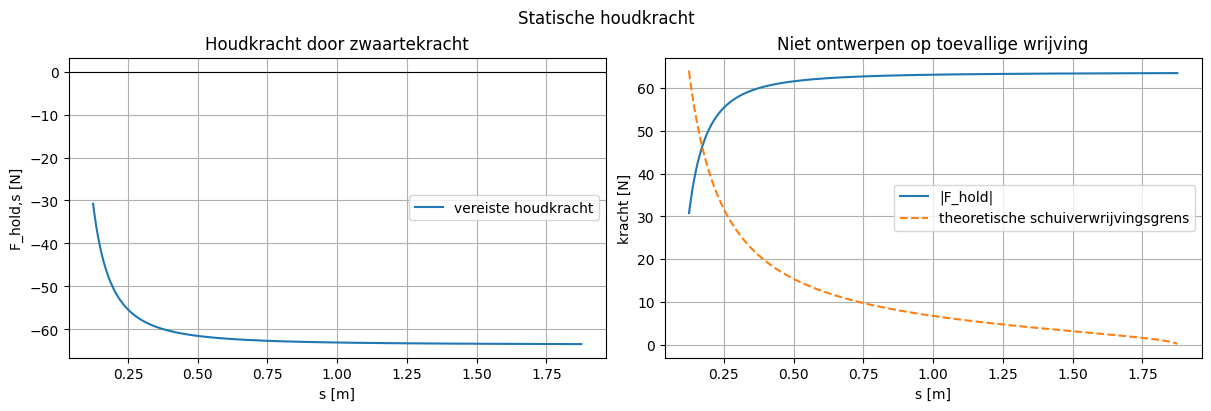

In [8]:
hold_curve_indices = np.argsort(s)
hold_s_curve = s[hold_curve_indices]
F_hold_s_curve = np.zeros_like(hold_s_curve)
R_Ax_hold_curve = np.zeros_like(hold_s_curve)
C_x_hold_curve = np.zeros_like(hold_s_curve)
C_y_hold_curve = np.zeros_like(hold_s_curve)

for out_i, k in enumerate(hold_curve_indices):
    A_hold, b_hold = build_inverse_dynamics_system(k, include_gravity=True, static=True)
    w_hold = np.linalg.solve(A_hold, b_hold)
    F_hold_s_curve[out_i] = -w_hold[unknown_index["F_act_y"]]
    R_Ax_hold_curve[out_i] = w_hold[unknown_index["R_Ax"]]
    C_x_hold_curve[out_i] = w_hold[unknown_index["C_x"]]
    C_y_hold_curve[out_i] = w_hold[unknown_index["C_y"]]

static_slider_capacity_curve = mu_slider_static * np.abs(R_Ax_hold_curve)
T_hold_motor_curve = F_hold_s_curve * screw_lead / (2 * np.pi * actuator_efficiency)
T_hold_lock_required_curve = actuator_safety_factor * np.abs(F_hold_s_curve) * screw_lead / (2 * np.pi * actuator_efficiency)

sample_targets = np.linspace(np.min(s), np.max(s), 5)
sample_indices_curve = np.array([int(np.argmin(np.abs(hold_s_curve - target))) for target in sample_targets])
hold_s_values = hold_s_curve[sample_indices_curve]
F_hold_s = F_hold_s_curve[sample_indices_curve]
R_Ax_hold = R_Ax_hold_curve[sample_indices_curve]
static_slider_capacity = static_slider_capacity_curve[sample_indices_curve]
T_hold_motor = T_hold_motor_curve[sample_indices_curve]
T_hold_lock_required = T_hold_lock_required_curve[sample_indices_curve]

open_idx_curve = int(np.argmin(hold_s_curve))
closed_idx_curve = int(np.argmax(hold_s_curve))
open_idx = int(np.argmin(hold_s_values))
closed_idx = int(np.argmax(hold_s_values))

print("Statische houdanalyse:")
for i, s_val in enumerate(hold_s_values):
    label = "open" if i == open_idx else ("gesloten" if i == closed_idx else "tussenstand")
    print(f"s = {s_val:.3f} m ({label:10s}) | F_hold = {F_hold_s[i]: .2f} N | theoretische schuiverwrijvingsgrens = {static_slider_capacity[i]:.2f} N")
print()
print(f"open stand: |F_hold| = {abs(F_hold_s_curve[open_idx_curve]):.2f} N")
print(f"open stand: spindel-/remkoppel met safety, zonder rekenen op wrijving = {T_hold_lock_required_curve[open_idx_curve]:.4f} Nm")

fig_hold, ax_hold = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_hold.suptitle("Statische houdkracht")
ax_hold[0].plot(hold_s_curve, F_hold_s_curve, label="vereiste houdkracht")
ax_hold[0].axhline(0.0, color="black", linewidth=0.8)
ax_hold[0].set_xlabel("s [m]"); ax_hold[0].set_ylabel("F_hold,s [N]")
ax_hold[0].set_title("Houdkracht door zwaartekracht")
ax_hold[0].grid(True); ax_hold[0].legend()

ax_hold[1].plot(hold_s_curve, np.abs(F_hold_s_curve), label="|F_hold|")
ax_hold[1].plot(hold_s_curve, static_slider_capacity_curve, "--", label="theoretische schuiverwrijvingsgrens")
ax_hold[1].set_xlabel("s [m]"); ax_hold[1].set_ylabel("kracht [N]")
ax_hold[1].set_title("Niet ontwerpen op toevallige wrijving")
ax_hold[1].grid(True); ax_hold[1].legend()
plt.show()

## Vermogen en actuatorbelasting

De actuator volgt het traject `s_ref(t)` uit Notebook 1. De kracht volgt uit de inverse dynamica en het mechanische vermogen aan de schuiver is `P = F_s ds`. Positief vermogen betekent dat de actuator energie aan het mechanisme levert. Negatief vermogen betekent dat het mechanisme de aandrijving zou terugduwen of dat er geremd moet worden.

Het getoonde vermogen in de grafiek is mechanisch vermogen aan de schuiver. In de geprinte motorwaarden wordt het actuatorrendement en de veiligheidsfactor gebruikt voor een eerste motordimensionering.

Actuatoranalyse met zwaartekracht en wrijving:
piek schuifkracht tijdens beweging   = 76.06 N
RMS schuifkracht tijdens beweging    = 66.68 N
max positief actuatorvermogen        = 31.48 W
max rem/regeneratief vermogen        = 0.00 W
netto mechanische energie            = 119.81 J
energiefluctuatie                    = 119.81 J
piek motortoerental                  = 2994.4 rpm
piek motorkoppel incl. safety        = 0.1135 Nm
RMS motorkoppel incl. safety         = 0.0995 Nm


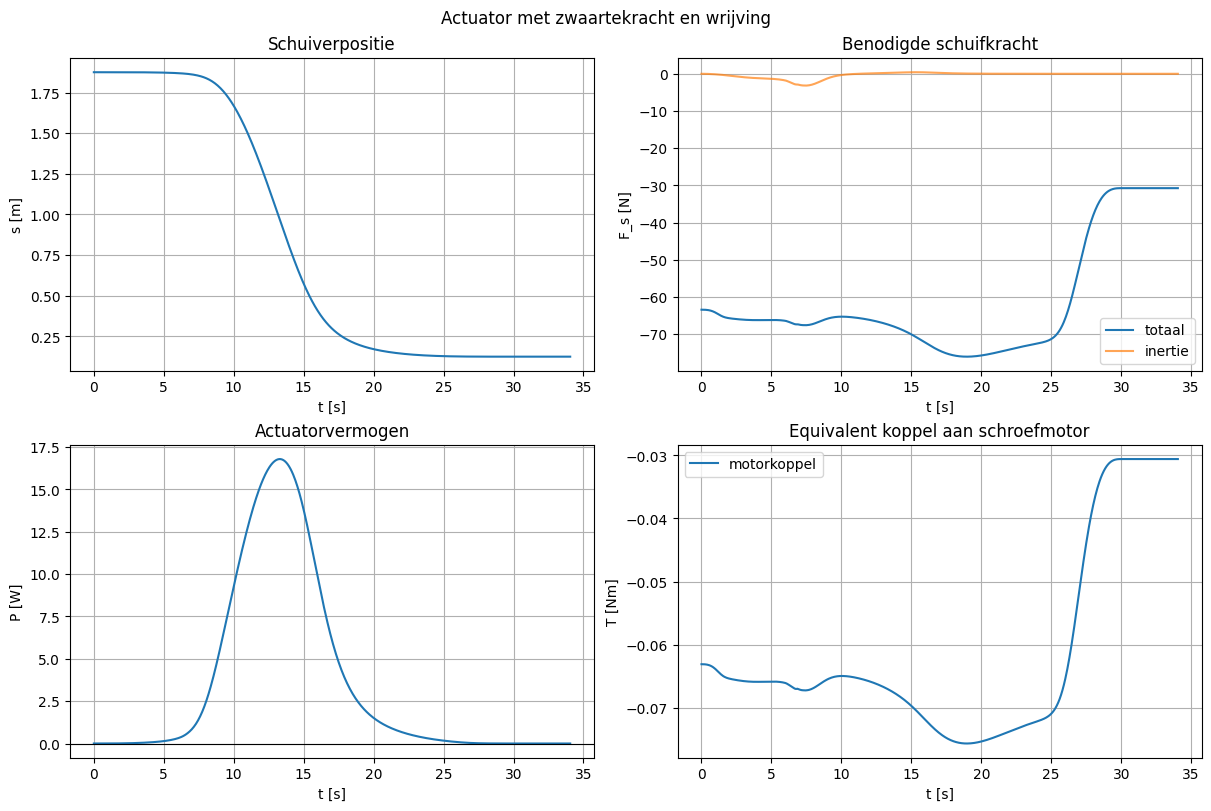

In [9]:
F_required_s_total = F_drive_s_total.copy()
P_act_total = F_required_s_total * ds
E_act_total = np.zeros_like(t)
E_act_total[1:] = np.cumsum(0.5 * (P_act_total[1:] + P_act_total[:-1]) * np.diff(t))

motor_speed_rps = ds / screw_lead
motor_speed_rpm = 60.0 * motor_speed_rps
T_motor_total = F_required_s_total * screw_lead / (2 * np.pi * actuator_efficiency)

motion_mask = np.abs(ds) > 1e-8
if not np.any(motion_mask):
    motion_mask = np.ones_like(ds, dtype=bool)

P_positive = np.maximum(P_act_total, 0.0)
P_negative = np.minimum(P_act_total, 0.0)
P_positive_peak = actuator_safety_factor * np.max(P_positive) / actuator_efficiency
P_regen_peak = actuator_safety_factor * abs(np.min(P_negative)) * actuator_efficiency
T_motor_peak = actuator_safety_factor * np.max(np.abs(T_motor_total))
T_motor_rms = actuator_safety_factor * np.sqrt(np.mean(T_motor_total[motion_mask]**2))
F_total_peak = np.max(np.abs(F_required_s_total[motion_mask]))
F_total_rms = np.sqrt(np.mean(F_required_s_total[motion_mask]**2))
energy_net_total = E_act_total[-1] - E_act_total[0]
energy_fluctuation_total = np.max(E_act_total) - np.min(E_act_total)

print("Actuatoranalyse met zwaartekracht en wrijving:")
print(f"piek schuifkracht tijdens beweging   = {F_total_peak:.2f} N")
print(f"RMS schuifkracht tijdens beweging    = {F_total_rms:.2f} N")
print(f"max positief actuatorvermogen        = {P_positive_peak:.2f} W")
print(f"max rem/regeneratief vermogen        = {P_regen_peak:.2f} W")
print(f"netto mechanische energie            = {energy_net_total:.2f} J")
print(f"energiefluctuatie                    = {energy_fluctuation_total:.2f} J")
print(f"piek motortoerental                  = {np.max(np.abs(motor_speed_rpm)):.1f} rpm")
print(f"piek motorkoppel incl. safety        = {T_motor_peak:.4f} Nm")
print(f"RMS motorkoppel incl. safety         = {T_motor_rms:.4f} Nm")

fig_act, ax_act = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_act.suptitle("Actuator met zwaartekracht en wrijving")
ax_act[0, 0].plot(t, s)
ax_act[0, 0].set_title("Schuiverpositie"); ax_act[0, 0].set_xlabel("t [s]"); ax_act[0, 0].set_ylabel("s [m]"); ax_act[0, 0].grid(True)
ax_act[0, 1].plot(t, F_required_s_total, label="totaal")
ax_act[0, 1].plot(t, F_drive_s_inertia, alpha=0.7, label="inertie")
ax_act[0, 1].set_title("Benodigde schuifkracht"); ax_act[0, 1].set_xlabel("t [s]"); ax_act[0, 1].set_ylabel("F_s [N]"); ax_act[0, 1].grid(True); ax_act[0, 1].legend()
ax_act[1, 0].plot(t, P_act_total)
ax_act[1, 0].axhline(0.0, color="black", linewidth=0.8)
ax_act[1, 0].set_title("Actuatorvermogen"); ax_act[1, 0].set_xlabel("t [s]"); ax_act[1, 0].set_ylabel("P [W]"); ax_act[1, 0].grid(True)
ax_act[1, 1].plot(t, T_motor_total, label="motorkoppel")
ax_act[1, 1].set_title("Equivalent koppel aan schroefmotor"); ax_act[1, 1].set_xlabel("t [s]"); ax_act[1, 1].set_ylabel("T [Nm]"); ax_act[1, 1].grid(True); ax_act[1, 1].legend()
plt.show()

## Framebelasting en onbalans

Onbalans en framebelasting zijn niet hetzelfde. De inertiele onbalans uit Notebook 2 hoort bij versnellingen en is klein omdat het traject traag is. Met zwaartekracht krijgt het frame daarbovenop een bijna statische gewichtslast. De afzonderlijke steunreacties aan de schuiver en aan C kunnen groot zijn door de mechanische overbrenging, zelfs als de netto resultante op het volledige frame ongeveer gelijk is aan het totale gewicht.

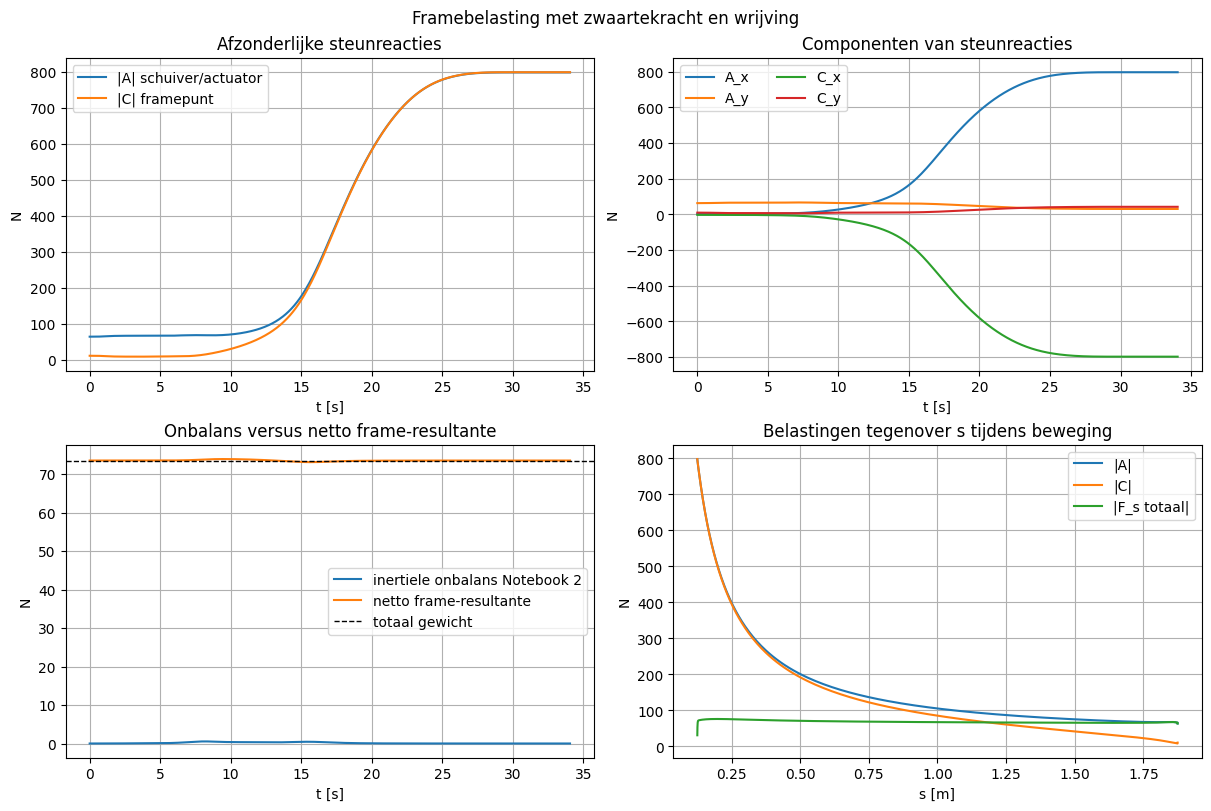

Framebelasting:
totaal gewicht model       = 73.57 N
max netto frame-resultante = 73.95 N
max frame-reactie aan C    = 798.40 N
max belasting aan schuiver = 797.85 N


In [10]:
F_slider_global = np.column_stack((np.zeros(n_steps), -case_total["F_slider_friction_s"]))
F_A_total = np.column_stack((vars_total["R_Ax"], vars_total["F_act_y"])) + F_slider_global
F_C_total = np.column_stack((vars_total["C_x"], vars_total["C_y"]))
F_frame_total = F_A_total + F_C_total
F_frame_total_norm = np.linalg.norm(F_frame_total, axis=1)
F_C_total_norm = np.linalg.norm(F_C_total, axis=1)
F_A_total_norm = np.linalg.norm(F_A_total, axis=1)
total_weight = total_model_mass * g

if "F_shak_norm" in dyn.files:
    F_shak_norm_inertia = dyn["F_shak_norm"]
else:
    F_shak_norm_inertia = np.linalg.norm(np.column_stack((dyn.get("F_shak_x", np.zeros(n_steps)), dyn.get("F_shak_y", np.zeros(n_steps)))), axis=1)

fig_frame, ax_frame = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_frame.suptitle("Framebelasting met zwaartekracht en wrijving")
ax_frame[0, 0].plot(t, F_A_total_norm, label="|A| schuiver/actuator")
ax_frame[0, 0].plot(t, F_C_total_norm, label="|C| framepunt")
ax_frame[0, 0].set_title("Afzonderlijke steunreacties")
ax_frame[0, 0].set_xlabel("t [s]"); ax_frame[0, 0].set_ylabel("N")
ax_frame[0, 0].grid(True); ax_frame[0, 0].legend()

ax_frame[0, 1].plot(t, F_A_total[:, 0], label="A_x")
ax_frame[0, 1].plot(t, F_A_total[:, 1], label="A_y")
ax_frame[0, 1].plot(t, F_C_total[:, 0], label="C_x")
ax_frame[0, 1].plot(t, F_C_total[:, 1], label="C_y")
ax_frame[0, 1].set_title("Componenten van steunreacties")
ax_frame[0, 1].set_xlabel("t [s]"); ax_frame[0, 1].set_ylabel("N")
ax_frame[0, 1].grid(True); ax_frame[0, 1].legend(ncol=2)

ax_frame[1, 0].plot(t, F_shak_norm_inertia, label="inertiele onbalans Notebook 2")
ax_frame[1, 0].plot(t, F_frame_total_norm, label="netto frame-resultante")
ax_frame[1, 0].axhline(total_weight, color="black", linestyle="--", linewidth=1.0, label="totaal gewicht")
ax_frame[1, 0].set_title("Onbalans versus netto frame-resultante")
ax_frame[1, 0].set_xlabel("t [s]"); ax_frame[1, 0].set_ylabel("N")
ax_frame[1, 0].grid(True); ax_frame[1, 0].legend()

ax_frame[1, 1].plot(s_motion[sort_motion], F_A_total_norm[active_motion_mask][sort_motion], label="|A|")
ax_frame[1, 1].plot(s_motion[sort_motion], F_C_total_norm[active_motion_mask][sort_motion], label="|C|")
ax_frame[1, 1].plot(s_motion[sort_motion], np.abs(F_required_s_total[active_motion_mask][sort_motion]), label="|F_s totaal|")
ax_frame[1, 1].set_title("Belastingen tegenover s tijdens beweging")
ax_frame[1, 1].set_xlabel("s [m]"); ax_frame[1, 1].set_ylabel("N")
ax_frame[1, 1].grid(True); ax_frame[1, 1].legend()
plt.show()

print("Framebelasting:")
print(f"totaal gewicht model       = {total_weight:.2f} N")
print(f"max netto frame-resultante = {np.max(F_frame_total_norm):.2f} N")
print(f"max frame-reactie aan C    = {np.max(F_C_total_norm):.2f} N")
print(f"max belasting aan schuiver = {np.max(F_A_total_norm):.2f} N")

## Opslag

De resultaten worden opgeslagen in `notebook3_gravity_friction_results.npz`. Dat bestand bevat de totale aandrijfkracht, de opsplitsing in inertie/zwaartekracht/wrijving, schuiver- en scharnierwrijving, actuatorgrootheden, framebelastingen en statische houdkrachten.

In [11]:
results_path = Path("notebook3_gravity_friction_results.npz").resolve()
np.savez(
    results_path,
    t=t, s=s, ds=ds, dds=dds,
    F_drive_s_inertia=F_drive_s_inertia,
    F_drive_s_gravity=F_drive_s_gravity,
    F_drive_s_total=F_drive_s_total,
    F_gravity_component=F_gravity_component,
    F_friction_component=F_friction_component,
    F_slider_drive_component=F_slider_drive_component,
    F_pin_friction_component=F_pin_friction_component,
    F_slider_friction_s=case_total["F_slider_friction_s"],
    N_slider=case_total["N_slider"],
    joint_friction_moments=case_total["joint_friction_moments"],
    joint_normal_forces=case_total["joint_normal_forces"],
    joint_power_loss=case_total["joint_power_loss"],
    pin_joint_names=np.array(pin_joint_names),
    R_Ax_total=vars_total["R_Ax"],
    C_x_total=vars_total["C_x"],
    C_y_total=vars_total["C_y"],
    M_A_total=vars_total["M_A"],
    F_A_total=F_A_total,
    F_C_total=F_C_total,
    F_frame_total=F_frame_total,
    F_A_total_norm=F_A_total_norm,
    F_C_total_norm=F_C_total_norm,
    F_frame_total_norm=F_frame_total_norm,
    P_act_total=P_act_total,
    E_act_total=E_act_total,
    T_motor_total=T_motor_total,
    motor_speed_rpm=motor_speed_rpm,
    hold_s_values=hold_s_values,
    F_hold_s=F_hold_s,
    R_Ax_hold=R_Ax_hold,
    static_slider_capacity=static_slider_capacity,
    hold_s_curve=hold_s_curve,
    F_hold_s_curve=F_hold_s_curve,
    R_Ax_hold_curve=R_Ax_hold_curve,
    static_slider_capacity_curve=static_slider_capacity_curve,
    T_hold_motor=T_hold_motor,
    T_hold_lock_required=T_hold_lock_required,
    T_hold_motor_curve=T_hold_motor_curve,
    T_hold_lock_required_curve=T_hold_lock_required_curve,
    masses=np.array([masses[i] for i in range(2, 9)]),
    inertias=np.array([inertias[i] for i in range(2, 9)]),
    payload_mass_K=payload_mass_K,
    line_mass_density=line_mass_density,
    slider_mass=slider_mass,
    total_model_mass=total_model_mass,
    g=g,
    mu_slider=mu_slider,
    mu_slider_static=mu_slider_static,
    c_slider=c_slider,
    mu_pin=mu_pin,
    pin_radius=pin_radius,
    actuator_efficiency=actuator_efficiency,
    actuator_safety_factor=actuator_safety_factor,
    screw_lead=screw_lead,
    total_weight=total_weight,
    dyn_residual_total=case_total["residual"],
    dyn_cond_total=case_total["cond"],
    max_diff_notebook2=max_diff_notebook2,
)

print("Notebook 3-resultaten opgeslagen in:")
print(results_path)
print()
print("SAMENVATTING")
print("=" * 52)
print(f"max |F_s| inertie                 : {np.max(np.abs(F_drive_s_inertia)):.2f} N")
print(f"max |F_s| met zwaartekracht       : {np.max(np.abs(F_drive_s_gravity)):.2f} N")
print(f"max |F_s| totaal                  : {np.max(np.abs(F_drive_s_total)):.2f} N")
print(f"open stand |F_hold|               : {abs(F_hold_s_curve[open_idx_curve]):.2f} N")
print(f"piek actuatorvermogen             : {P_positive_peak:.2f} W")
print(f"piek motorkoppel spindel          : {T_motor_peak:.4f} Nm")
print(f"max steunreactie schuiver/actuator : {np.max(F_A_total_norm):.2f} N")
print(f"max steunreactie C                 : {np.max(F_C_total_norm):.2f} N")
print(f"max netto framekracht              : {np.max(F_frame_total_norm):.2f} N")
print(f"validatie t.o.v. Notebook 2        : {max_diff_notebook2:.3e} N")

Notebook 3-resultaten opgeslagen in:
C:\Users\alecv\Git\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook3_gravity_friction_results.npz

SAMENVATTING
max |F_s| inertie                 : 3.17 N
max |F_s| met zwaartekracht       : 66.60 N
max |F_s| totaal                  : 76.06 N
open stand |F_hold|               : 30.75 N
piek actuatorvermogen             : 31.48 W
piek motorkoppel spindel          : 0.1135 Nm
max steunreactie schuiver/actuator : 797.85 N
max steunreactie C                 : 798.40 N
max netto framekracht              : 73.95 N
validatie t.o.v. Notebook 2        : 0.000e+00 N
